### Verify the notebook is using the correct Python.

In [1]:
import sys
print(sys.executable)

c:\Personal\pm-linearregression\.venv\Scripts\python.exe


### 0. Environment & Path Configuration

To maintain a clean, modular project structure, our core OOP logic is encapsulated in the `src/` directory, while this execution notebook resides in the `notebooks/` directory. 

The following cell dynamically updates the Python system path (`sys.path`) to include the project root. This ensures the notebook can seamlessly import our custom modules (e.g., `data_loader`, `preprocessing`, `model`) regardless of the working directory from which Jupyter is launched.

In [2]:
import sys
import os

# Bulletproof path hack: Finds the project root and adds it to Python's search path
current_dir = os.path.abspath(os.getcwd())

# If Jupyter launched from inside the 'notebooks' folder, go up one level to the root
if current_dir.endswith('notebooks'):
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

# Insert at the beginning of sys.path so it takes priority
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✅ Python path updated. Project root: {project_root}")

✅ Python path updated. Project root: c:\Personal\pm-linearregression


### 1. Database Connection and Data Ingestion

To satisfy the requirement of utilizing a cloud-based relational database, we first establish a secure connection to a **Neon.tech PostgreSQL** instance using environment variables. 

The raw training dataset (`RMBR4-2_export_test.csv`) is ingested into the application via `pandas` and subsequently uploaded to the Neon database. To ensure strict adherence to the pipeline requirements, the training data is then queried *back* from the database into the application to be used for model training, simulating a real-world production environment where models are trained directly from a centralized data warehouse.

In [3]:
import pandas as pd
from src.data_loader import DatabaseManager

# 1. Initialize the Database Manager
db = DatabaseManager()

# 2. Load the original CSV into pandas
training_csv_path = "../data/RMBR4-2_export_test.csv"
df_raw = pd.read_csv(training_csv_path)

# 3. Push the CSV data into Neon
db.upload_training_data(df_raw, table_name="training_telemetry")

# 4. PULL the data back from Neon
df_training = db.fetch_training_data(table_name="training_telemetry")

# Now df_training is ready to be passed to preprocessing.py and model.py
print(df_training.head())


✅ Successfully connected to Neon Database.
✅ Uploaded 39672 rows to table 'training_telemetry'.
✅ Fetched 39672 rows from table 'training_telemetry' for training.
     Trait  Axis #1  Axis #2  Axis #3  Axis #4  Axis #5  Axis #6  Axis #7  \
0  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4  current      0.0      0.0      0.0      0.0      0.0      0.0      0.0   

   Axis #8 Axis #9 Axis #10 Axis #11 Axis #12 Axis #13 Axis #14  \
0      0.0    None     None     None     None     None     None   
1      0.0    None     None     None     None     None     None   
2      0.0    None     None     None     None     None     None   
3      0.0    None     None     None     None     None     None   
4      0.0    None     None     None   

### 2. Data Preprocessing, Normalization, and Synthetic Data Generation

Before training our regression models, we must preprocess the data to ensure all axes are on a comparable scale and generate synthetic testing data based on the training metadata. 

To prevent **data leakage**, all scaling parameters (mean, standard deviation, min, max) are derived **strictly from the training data**. These exact parameters are then applied to the synthetic testing data, satisfying the requirement to normalize and standardize *"with respect to the training data."*

#### Scaling Techniques Applied:
1. **Min-Max Normalization:** Rescales the raw training data to a fixed range of [0, 1] using the formula $X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$. This ensures axes with larger raw magnitudes do not disproportionately bias the models.
2. **Standardization (Z-Scores):** Transforms the data to have a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1 using the formula $Z = \frac{X - \mu}{\sigma}$. 
   * *Note:* Z-scores are critical for the next phase of the pipeline. By standardizing the data, we can analyze the regression residuals in terms of standard deviations, allowing us to mathematically justify our anomaly thresholds (e.g., flagging deviations $> 2\sigma$ or $> 3\sigma$).

#### Synthetic Testing Data:
Using the extracted metadata (mean and standard deviation) of the normalized training data, we generate a synthetic testing dataset using a normal distribution. We also intentionally inject continuous anomalies into this synthetic stream to simulate real-world predictive maintenance failures, ensuring our alert/error logic has valid edge-cases to detect.

In [4]:
from src.preprocessing import DataPreprocessor

# 1. Define your axis columns
my_axes = ['Axis #1', 'Axis #2', 'Axis #3', 'Axis #4', 'Axis #5', 'Axis #6', 'Axis #7', 'Axis #8'] 

# 2. Initialize the Preprocessor
preprocessor = DataPreprocessor(axis_columns=my_axes)

# 3. NEW STEP: Convert timestamp strings to numeric seconds BEFORE doing anything else
df_training = preprocessor.convert_timestamps(df_training)

# 4. Generate the Synthetic Testing Data
df_synthetic_raw = preprocessor.generate_synthetic_data(df_training, n_samples=1000)

# 5. Fit Scalers on Training Data, and Transform BOTH datasets
df_train_scaled, df_synth_scaled = preprocessor.fit_and_transform(df_training, df_synthetic_raw)

# 6. Save the synthetic testing data to a CSV (Required for the CSV -> DB streaming step later!)
df_synth_scaled.to_csv('../data/synthetic_testing_stream.csv', index=False)
print("✅ Saved synthetic testing data to ../data/synthetic_testing_stream.csv")

# Quick look at the data
print("\n--- Scaled Training Data ---")
print(df_train_scaled.head())

🔄 Converting timestamp strings to numeric seconds...
✅ Time column converted. Range: 0 to 80795.0 seconds.
🔄 Generating synthetic testing data from training metadata...
✅ Generated 1000 rows. Injected continuous anomaly from index 400 to 450.
🔄 Fitting scalers on training data and transforming both datasets...
✅ Data successfully normalized and standardized with respect to training data.
✅ Saved synthetic testing data to ../data/synthetic_testing_stream.csv

--- Scaled Training Data ---
     Trait   Axis #1   Axis #2   Axis #3   Axis #4   Axis #5   Axis #6  \
0  current -0.335667 -0.525209 -0.530208 -0.393822 -0.454499 -0.330176   
1  current -0.335667 -0.525209 -0.530208 -0.393822 -0.454499 -0.330176   
2  current -0.335667 -0.525209 -0.530208 -0.393822 -0.454499 -0.330176   
3  current -0.335667 -0.525209 -0.530208 -0.393822 -0.454499 -0.330176   
4  current -0.335667 -0.525209 -0.530208 -0.393822 -0.454499 -0.330176   

    Axis #7   Axis #8 Axis #9 Axis #10 Axis #11 Axis #12 Axis #

### 3. Regression Modeling, Residual Analysis, and Threshold Discovery

To establish a baseline for normal machine behavior, we fit 8 separate univariate linear regression models, mapping `Time` to each of the 8 current axes. 

#### Residual Analysis & Threshold Discovery
Instead of using arbitrary fixed thresholds, we analyze the **residuals** (the difference between the observed current and the predicted current). By calculating the standard deviation ($\sigma$) of these residuals, we can use **Z-scores** to mathematically justify our anomaly thresholds:
* **MinC (Alert Threshold):** Set at $2\sigma$ above the regression line. A deviation of this magnitude is statistically unusual (~2.5% probability in a normal distribution) and warrants an early warning for predictive maintenance.
* **MaxC (Error Threshold):** Set at $3\sigma$ above the regression line. A deviation of this size is highly anomalous (~0.1% probability) and indicates an imminent failure state requiring an immediate Error flag.
* **T (Time Window):** Set to 5 continuous seconds. To prevent false positives from momentary electrical spikes, the deviation must persist for at least $T$ seconds to trigger an Alert or Error.

🔄 Fitting 8 Linear Regression models...
✅ Successfully fitted models for 8 axes.
🔄 Analyzing residuals and discovering thresholds...


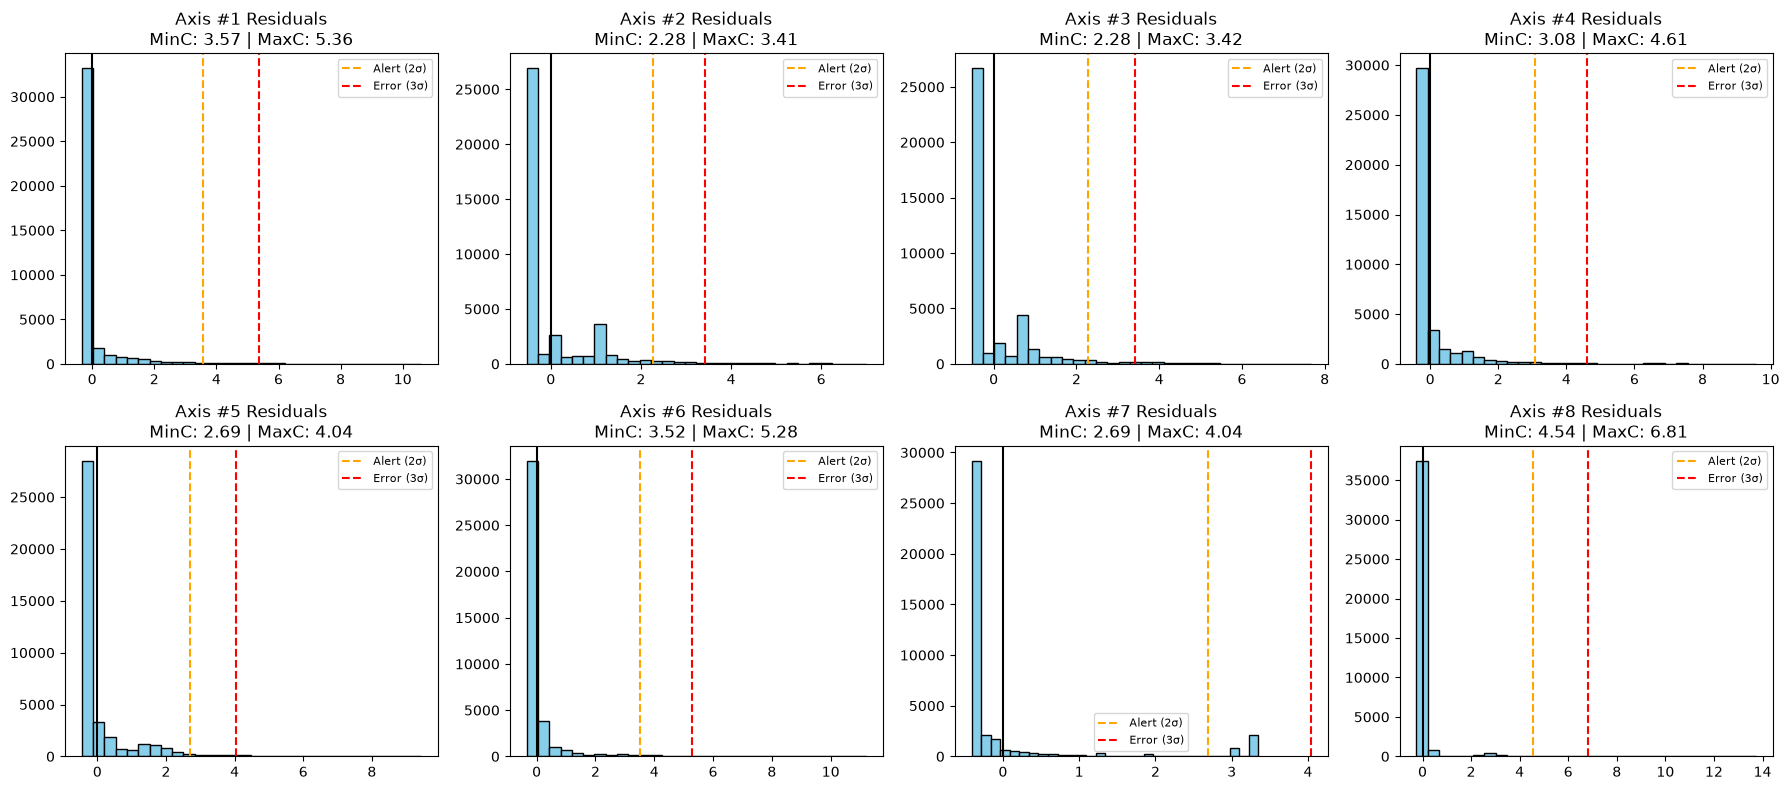

✅ Thresholds discovered and residual distributions plotted.
🔄 Evaluating streaming data with T=5s window...
✅ Stream evaluation complete. Detected 14 events.

--- Triggered Events Log ---
        Time     Axis   Type  Residual  Duration
0  81199.968  Axis #3  ERROR  6.340582         5
1  81202.968  Axis #1  ALERT  4.225423         5
2  81204.968  Axis #3  ERROR  6.198379         5
3  81206.968  Axis #1  ERROR  7.200173         5
4  81209.968  Axis #3  ERROR  5.825342         5
5  81214.968  Axis #3  ERROR  6.303206         5
6  81219.968  Axis #3  ERROR  5.955841         5
7  81224.968  Axis #3  ERROR  6.158629         5
8  81229.968  Axis #1  ALERT  5.312964         5
9  81229.968  Axis #3  ERROR  7.110453         5


In [5]:
# In your Jupyter Notebook
from src.model import RegressionAnalyzer

# 1. Initialize the Analyzer
analyzer = RegressionAnalyzer(axis_columns=my_axes) # Axes previously defined in preprocessing.py

# 2. Fit the models on the SCALED training data
analyzer.fit_models(df_train_scaled)

# 3. Analyze residuals and discover MinC, MaxC thresholds
# (This will output the 8 residuals histograms and the discovered thresholds for each axis)
analyzer.analyze_residuals_and_discover_thresholds(df_train_scaled)

# 4. Evaluate the synthetic streaming data to find the Alerts and Errors
# (Remember df_synth_scaled from the preprocessing step)
events_df = analyzer.evaluate_stream(df_synth_scaled)

# Let's look at the events we triggered!
print("\n--- Triggered Events Log ---")
print(events_df.head(10))

### 4. Streaming Simulation and Event Logging

To satisfy the requirement of simulating a real-time industrial environment, we implemented a `StreamingSimulator` class. This script reads the synthetically generated testing data (`synthetic_testing_stream.csv`) row-by-row and inserts it into the Neon `streaming_telemetry` table. A slight time delay (`time.sleep()`) is applied to mimic the continuous time-based flow of physical IoT sensors.

As the data streams through the application, it is evaluated against the discovered `MinC`, `MaxC`, and `T` thresholds. All triggered predictive maintenance events are captured and logged into a structured CSV file (`alert_error_log.csv`) for auditing and further analysis.

### 5. Visualization Dashboard

The final dashboard overlays the streamed testing data and the trained linear regression lines for all 8 axes. 
* **Blue Line:** The expected baseline current (Regression prediction).
* **Gray Dots:** The actual streamed synthetic sensor data.
* **Orange Triangles:** Triggered **Alerts** (deviations $\ge 2\sigma$ sustained for $T$ seconds).
* **Red Stars:** Triggered **Errors** (deviations $\ge 3\sigma$ sustained for $T$ seconds).

This visual confirmation proves that the regression-based anomaly detection successfully identifies the injected continuous anomalies, validating our threshold discovery process.

🔄 Starting stream simulation from ../data/synthetic_testing_stream.csv...
✅ Prepared 'streaming_telemetry' table for streaming inserts.
   ⏳ Streamed 100/1000 rows to Neon...
   ⏳ Streamed 200/1000 rows to Neon...
   ⏳ Streamed 300/1000 rows to Neon...
   ⏳ Streamed 400/1000 rows to Neon...
   ⏳ Streamed 500/1000 rows to Neon...
   ⏳ Streamed 600/1000 rows to Neon...
   ⏳ Streamed 700/1000 rows to Neon...
   ⏳ Streamed 800/1000 rows to Neon...
   ⏳ Streamed 900/1000 rows to Neon...
   ⏳ Streamed 1000/1000 rows to Neon...
✅ Stream complete! 1000 rows inserted into Neon.
🔄 Evaluating streaming data with T=5s window...
✅ Stream evaluation complete. Detected 14 events.
✅ Logged 14 events to ../data/alert_error_log.csv
🔄 Generating final regression plots with Alert/Error overlays...


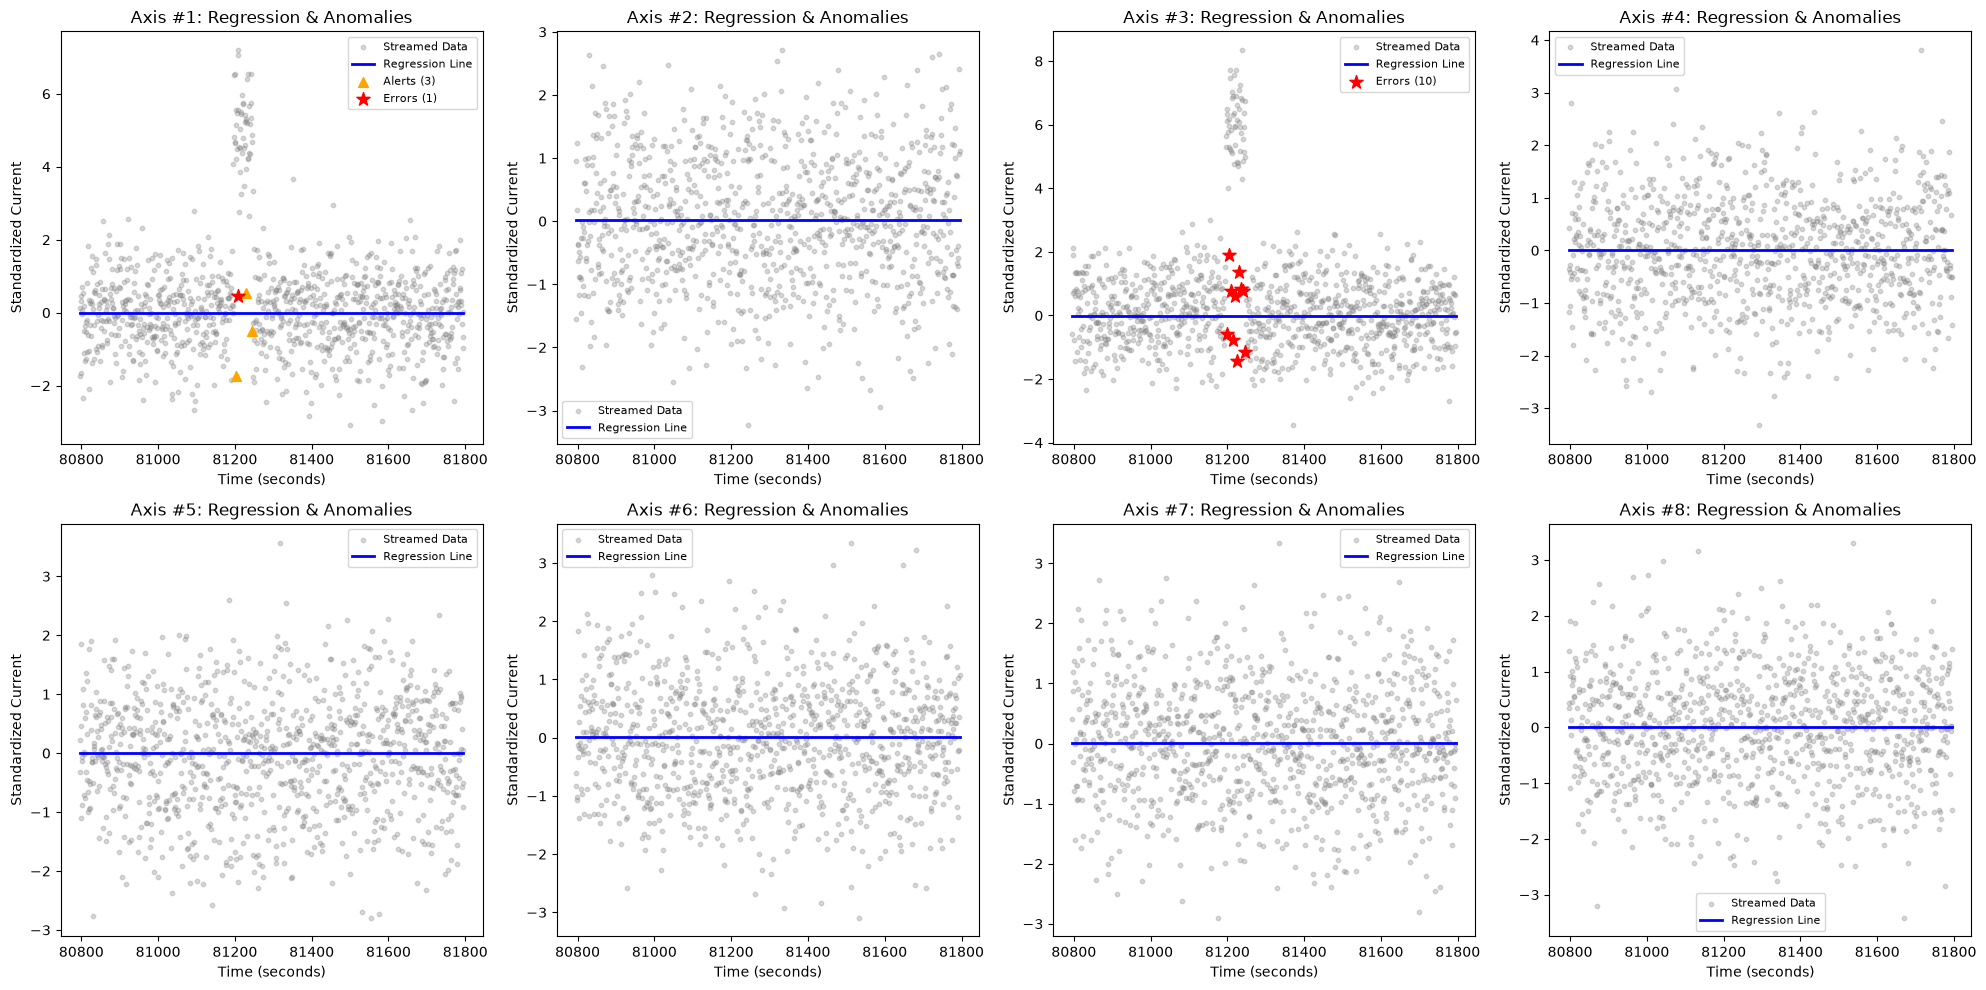

✅ Final visualizations generated.


In [ ]:
# --- SECTION 4: STREAMING SIMULATION & LOGGING ---
from src.streaming_simulator import StreamingSimulator

# 1. Initialize the Simulator
# (Adjust the path to your synthetic CSV based on your folder structure)
simulator = StreamingSimulator(
    db_manager=db, 
    analyzer=analyzer, 
    csv_path='../data/synthetic_testing_stream.csv', # Adjust path if needed!
    delay=0.01 # Set to 0.01s so it runs fast, but you can increase it to see it "stream"
)

# 2. Run the Stream (This pushes data to Neon and evaluates it)
df_streamed, events_df = simulator.run_stream()

# 3. Log the results to a CSV
events_df.to_csv('../data/alert_error_log.csv', index=False)
print(f"✅ Logged {len(events_df)} events to ../data/alert_error_log.csv")

# --- SECTION 5: VISUALIZATION & DASHBOARD ---
# 4. Generate the final plots with overlays
analyzer.plot_regression_with_alerts(df_streamed, events_df)